In [2]:
import sys, os
import importlib
sys.path.append('../')

from modules.utils.imports import *
from modules.binn_eql.model_wrapper_2d import model_wrapper
from modules.binn_eql.build_binn_eql_net import BINN
from modules.loaders.format_data import format_data_general
from modules.loaders.visualize_training_data import animate_data
from modules.utils.noise_and_interpolate import noise_and_interpolate
from modules.utils.training_test_split import training_test_split
from modules.analysis.generate_loss_curves import generate_loss_curves
from modules.binn_eql.simulate_surface import simulate_surface
from modules.binn_eql.visualize_surface import visualize_surface
from modules.generate_data.simulate_system import wave_pinning

In [4]:
# load params from configuration file
dir_name = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/diff_coeffs/1_first_attempt/du_0.01_dv_0.1/binn_eql_gls_1_pde_1_l05_0.01_repeat_8'
config = {}
exec(Path(f'{dir_name}/config.cfg').read_text(encoding="utf8"), {}, config)

# Training data params
training_data_path = config['training_data_path']
species = int(config['species'])
dimensions = int(config['dimensions'])
epsilon = float(config['epsilon'])
points = int(config['points'])

# BINN params
diff_coeffs = [float(x) for x in config['diff_coeffs'].strip("()").split()]

# Symbolic Net params
duplicates = int(config['duplicates'])
degree = int(config['degree'])
gls_weight=float(config['gls_weight'])
pde_weight=float(config['pde_weight'])
l05_weight = float(config['l05_weight'])
l1_weight = float(config['l1_weight'])
param_bounds = float(config['param_bounds'])

In [10]:
training_data_path = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/data/2d/wave_pinning/select/du_0.01_dv_0.1.npz'

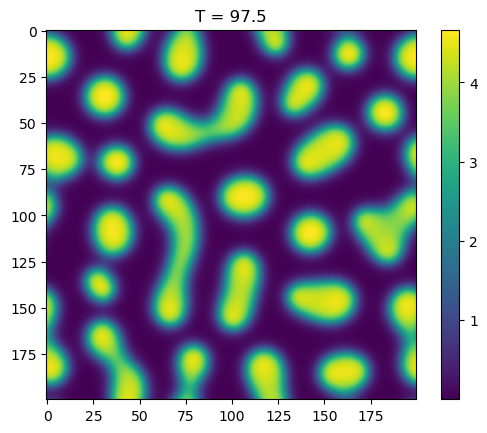

In [11]:
# Get GPU
device = 'cpu'

# Load training data (columns: x*dimensions, t, species concentrations)
training_data = format_data_general(dimensions, species, file=training_data_path)

# Add noise to training data if specified in config file
if epsilon != 0 or points != 0:
    training_data = noise_and_interpolate(training_data, points, epsilon, dimensions, species)

animate_data(training_data, dimensions, species, name=f'{dir_name}/training_data')

# Split training data
x_train, y_train, x_val, y_val = training_test_split(training_data, dimensions, device)

# initialize model and compile
binn = BINN(
    dimensions=dimensions,
    species=species, 
    duplicates=duplicates,
    data=x_train.cpu(), 
    diff_coeffs=diff_coeffs,
    degree=degree,
    gls_weight=gls_weight,
    pde_weight=pde_weight,
    l05_weight=l05_weight,
    l1_weight=l1_weight,
    param_bounds=param_bounds)

binn.to(device)

parameters = binn.parameters()

opt = torch.optim.Adam(parameters, lr=0.001)

model = model_wrapper(
    model=binn,
    optimizer=opt,
    loss=binn.loss,
    augmentation=None,
    save_name=f'{dir_name}/binn')
